# Clase 44 — Regresión lineal

Notebook introductorio para **predecir un número continuo** con scikit-learn.

**Caso:** mortalidad por cáncer de piel por estado de EE.UU. (`datos/skincancer.csv`). Dataset educativo público: a mayor latitud (menos sol), suele bajar la mortalidad.

**Cómo usarlo:** ejecutá las celdas en orden.

### Objetivos

1. Entender **por qué** transformamos los datos antes de modelar.
2. Separar train/test sin filtrar información del test.
3. Entrenar `LinearRegression`, interpretar coeficiente e intercepto.
4. Evaluar con MAE, RMSE y R².
5. Guardar y recargar el modelo con `joblib`.

### Requisitos

- Entorno **`.venv`** con `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`, `joblib`.
- Kernel **Python (.venv)** en VS Code o Cursor.


## Paso 0 — Importar librerías


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")


## Paso 1 — Leer dataset

Cargamos el CSV y hacemos una revisión rápida.


In [3]:
df = pd.read_csv(Path("datos") / "skincancer.csv")

print("Filas:", len(df), "| Columnas:", len(df.columns))
df.head()


Filas: 49 | Columnas: 5


,State,Lat,Mort,Ocean,Long
0,Alabama,33.0,219,1,87.0
1,Arizona,34.5,160,0,112.0
2,Arkansas,35.0,170,0,92.5
3,California,37.5,182,1,119.5
4,Colorado,39.0,149,0,105.5


In [4]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   State   49 non-null     str    
 1   Lat     49 non-null     float64
 2   Mort    49 non-null     int64  
 3   Ocean   49 non-null     int64  
 4   Long    49 non-null     float64
dtypes: float64(2), int64(2), str(1)
memory usage: 2.0 KB


,Lat,Mort,Ocean,Long
count,49.000000,49.000000,49.000000,49.000000
mean,39.532653,152.877551,0.448980,90.936735
std,4.610874,33.428177,0.502545,14.866485
min,28.000000,86.000000,0.000000,69.000000
25%,36.000000,128.000000,0.000000,78.500000
50%,39.500000,147.000000,0.000000,89.500000
75%,43.000000,178.000000,1.000000,100.000000
max,47.500000,229.000000,1.000000,121.000000


## Paso 2 — Por qué transformar

Antes de entrenar, preparamos los datos para que el modelo y el código sean claros.

| Situación | Qué hacemos | Por qué |
|-----------|-------------|---------|
| Nombres abreviados (`Lat`, `Mort`) | `rename` a nombres claros | El código se lee mejor en clase y en producción |
| Objetivo poco explícito | Renombrar `Mort` → `mortalidad` | Dejamos claro qué estamos prediciendo |
| `State` es texto (estado) | No lo usamos en el modelo simple | La regresión lineal necesita números |
| Mezclar predictores y objetivo | Separar `X` e `y` después | Evita confundir variables independientes y dependiente |

> **Regla:** primero limpiamos/renombramos; después separamos train/test; recién ahí entrenamos.


### Paso 2.1 — Transformar columnas

Empezamos con un modelo **simple**: una sola variable predictora (`latitud`).


In [ ]:
df = df.rename(columns={
    "Lat": "latitud",
    "Mort": "mortalidad",
    "Ocean": "costa",
    "Long": "longitud",
})

# Guardamos una copia con costa para el modelo de 2 variables (paso 7)
df_completo = df.copy()

df = df[["latitud", "mortalidad"]]
df.head()


,latitud,mortalidad
0,33.0,219
1,34.5,160
2,35.0,170
3,37.5,182
4,39.0,149


## Paso 3 — Separar train y test

El conjunto de **test** simula datos futuros: no debe usarse para decidir el modelo.

Si miramos el test para elegir variables o “ajustar a mano”, hay **fuga de datos** y las métricas quedan demasiado optimistas.


In [ ]:
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
)

print("Train:", len(df_train), "filas")
print("Test:", len(df_test), "filas")


Train: 39 filas
Test: 10 filas


## Paso 4 — Exploración en train

Solo exploramos el **train**. ¿Se ve una relación lineal entre latitud y mortalidad?


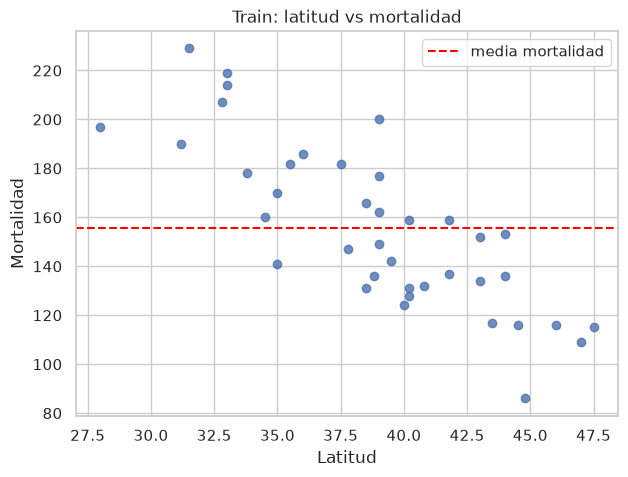

Parece relación lineal negativa: a mayor latitud, menor mortalidad.


In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(df_train["latitud"], df_train["mortalidad"], alpha=0.8)
plt.axhline(df_train["mortalidad"].mean(), linestyle="--", color="red", label="media mortalidad")
plt.xlabel("Latitud")
plt.ylabel("Mortalidad")
plt.title("Train: latitud vs mortalidad")
plt.legend()
plt.show()

print("Parece relación lineal negativa: a mayor latitud, menor mortalidad.")


## Paso 5 — Entrenar el modelo

- **X**: variables predictoras (aquí solo `latitud`)
- **y**: variable objetivo (`mortalidad`)

`fit` aprende la recta: `mortalidad ≈ intercepto + coeficiente * latitud`.


In [8]:
X_train = df_train[["latitud"]]
y_train = df_train["mortalidad"]
X_test = df_test[["latitud"]]
y_test = df_test["mortalidad"]

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Intercepto:", round(modelo.intercept_, 2))
print("Coeficiente (latitud):", round(modelo.coef_[0], 2))
print()
print("Interpretación: por cada grado más de latitud,")
print("la mortalidad estimada cambia en", round(modelo.coef_[0], 2), "unidades.")


Intercepto: 383.14
Coeficiente (latitud): -5.84

Interpretación: por cada grado más de latitud,
la mortalidad estimada cambia en -5.84 unidades.


## Paso 6 — Evaluar en test

| Métrica | Qué mide |
|---------|----------|
| **MAE** | Error promedio absoluto (en unidades de mortalidad) |
| **RMSE** | Castiga más los errores grandes |
| **R²** | Qué proporción de la varianza explica el modelo (1 = perfecto) |

Comparamos también con un **baseline ingenuo**: siempre predecir la media del train.


In [ ]:
y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

# Baseline: siempre la media del train
y_baseline = np.repeat(y_train.mean(), len(y_test))
mae_base = mean_absolute_error(y_test, y_baseline)
r2_base = r2_score(y_test, y_baseline)

print("Modelo lineal")
print("  MAE :", round(mae, 2))
print("  RMSE:", round(rmse, 2))
print("  R²  :", round(r2, 3))
print()
print("Baseline (media)")
print("  MAE :", round(mae_base, 2))
print("  R²  :", round(r2_base, 3))


Modelo lineal
  MAE : 12.31
  RMSE: 16.13
  R²  : 0.719

Baseline (media)
  MAE : 31.25
  R²  : -0.194


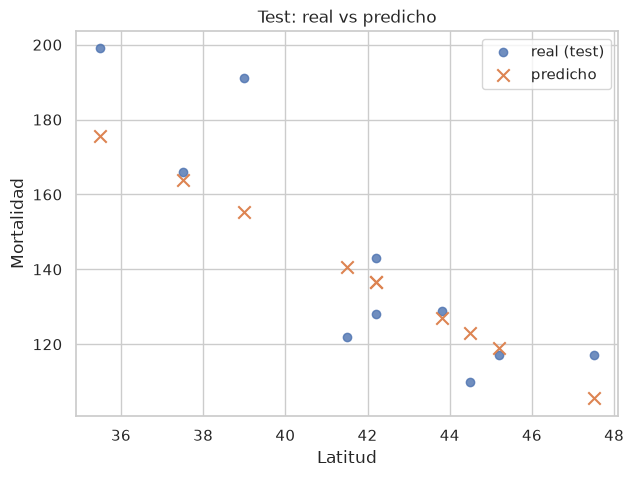

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(X_test["latitud"], y_test, label="real (test)", alpha=0.8)
plt.scatter(X_test["latitud"], y_pred, label="predicho", marker="x", s=80)
plt.xlabel("Latitud")
plt.ylabel("Mortalidad")
plt.title("Test: real vs predicho")
plt.legend()
plt.show()


## Paso 7 — Modelo con 2 variables (breve)

¿Mejora si agregamos `costa` (1 = toca el océano, 0 = no)?


In [11]:
df2 = df_completo[["latitud", "costa", "mortalidad"]]

df2_train, df2_test = train_test_split(df2, test_size=0.2, random_state=42)

X2_train = df2_train[["latitud", "costa"]]
y2_train = df2_train["mortalidad"]
X2_test = df2_test[["latitud", "costa"]]
y2_test = df2_test["mortalidad"]

modelo2 = LinearRegression()
modelo2.fit(X2_train, y2_train)

y2_pred = modelo2.predict(X2_test)
r2_dos = r2_score(y2_test, y2_pred)

print("R² con solo latitud :", round(r2, 3))
print("R² con latitud+costa:", round(r2_dos, 3))
print("Coeficientes:", dict(zip(["latitud", "costa"], np.round(modelo2.coef_, 2))))


R² con solo latitud : 0.719
R² con latitud+costa: 0.608
Coeficientes: {'latitud': np.float64(-4.95), 'costa': np.float64(25.37)}


## Paso 8 — Guardar el modelo

Guardamos el modelo de **una variable** (el principal de la clase) para reutilizarlo después sin reentrenar.


In [12]:
Path("modelos").mkdir(exist_ok=True)
ruta = Path("modelos") / "regresion_lineal_piel.joblib"

joblib.dump(modelo, ruta)
print("Modelo guardado en:", ruta)


Modelo guardado en: modelos/regresion_lineal_piel.joblib


In [18]:
# Cargar y predecir un ejemplo nuevo
modelo_cargado = joblib.load(ruta)

ejemplo = pd.DataFrame({"latitud": [30.0]})
prediccion = modelo_cargado.predict(ejemplo)

print("Para latitud 40.0, mortalidad estimada:", round(prediccion[0], 1))


Para latitud 40.0, mortalidad estimada: 207.8


## Cierre

Checklist del flujo:

1. Cargar datos  
2. **Transformar** (nombres claros, elegir columnas)  
3. **Separar** train / test  
4. **Entrenar** en train  
5. **Evaluar** en test (MAE, RMSE, R²)  
6. **Guardar** con `joblib`

En la [Clase 45](Clase_45_regresion_logistica.ipynb) veremos el mismo flujo para **clasificar** (0/1) con regresión logística.
